### Графики теоретические


50
92.04107626128214 temp of cold
7.958923738717877 temp of hot
30.106229608426222 изменение энтропии для скольки то там
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[np.float64(0.1347816258288359), np.float64(0.2483939406270108), np.float64(0.3117124558827976), np.float64(0.32585164732769334), np.float64(0.2936716940123307), np.float64(0.218363265848354), np.float64(0.1031929663377011), np.float64(0.048568899190465746), np.float64(0.233679179024904), np.float64(0.448941659582606), np.float64(0.691223478340461), np.float64(0.9574701260705847), np.float64(1.2447193907406398), np.float64(1.550114154399801), np.float64(1.8709138685978521), np.float64(2.204504555947481), np.float64(2.548407235337609), np.float64(2.9002847199035338), np.float64(3.2579467822174304), np.float64(3.619353718567043), np.float64(3.9826183739740464), np.float64(4.346006712667582), np.float64(4.707937036035113)

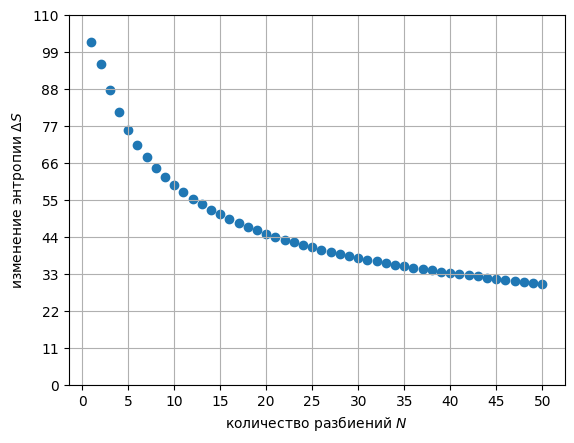

(np.float64(-4.356498983068256e-05), np.float64(0.0015901494666361443))
9.995490504057623


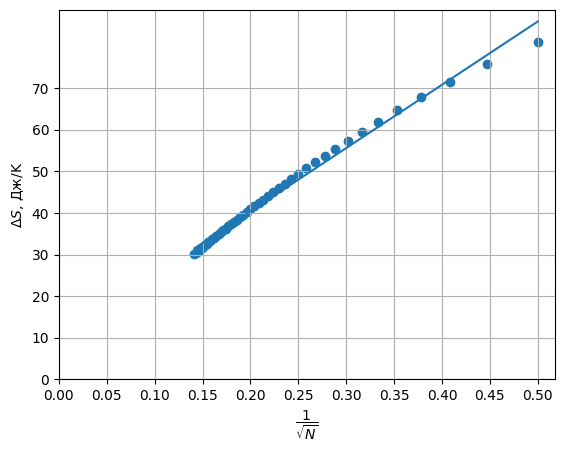

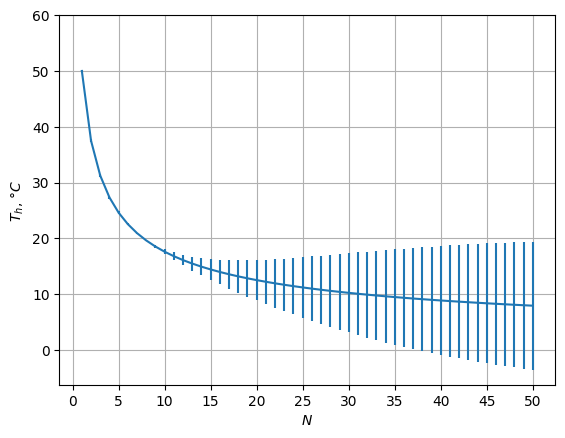

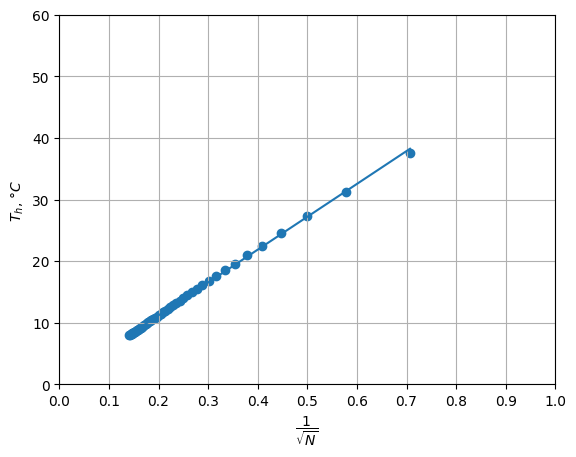

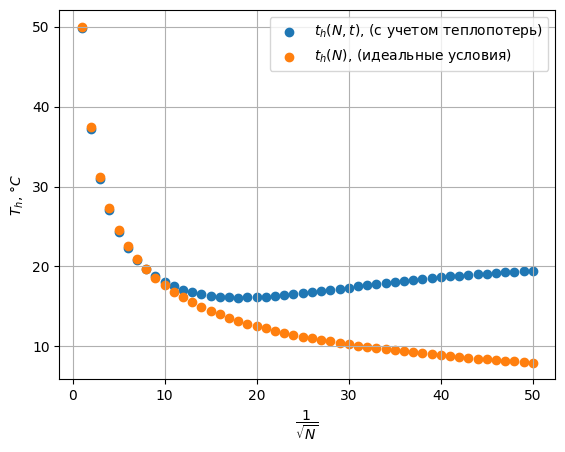

In [ ]:
from numpy import log
import numpy as np
from numpy import average as avg
import matplotlib.pyplot as plt
from scipy.special import factorial
fig, ax = plt.subplots()

#def f(n):
#  cold=[0]*n
#  hot=[100]*n
#  for i in range(n):
#    for j in range(n):
#      hot[j]=(cold[i]+hot[j])/2
#      cold[i]=hot[j]
#  return [cold, hot]

from numba import njit

@njit



def f(n):
    cold = np.zeros(n)
    hot = np.full(n, 100.0)
    for i in range(n):
        t = cold[i]
        for j in range(n):
            t = (t + hot[j]) / 2.0
            hot[j] = t
        cold[i] = t
    return cold, hot
#это формула для определения температур горячей и холодной воды после их смешивания


n=int(input())
#на сколько частей мы разбили воду


T_C=sum(f(n)[0])/n
T_H=sum(f(n)[1])/n
#ой температуры холодной и горячей воды после смешивания
print(T_C, "temp of cold")
print(T_H, "temp of hot")

delta_S=4200*log((273+T_C)*(273+T_H)/273/373)
#изменеение энтропии в конце процесса для идеального случая
print(delta_S, 'изменение энтропии для скольки то там')

alpha=0.0045
#коэффициент для формулы в техе
if n<20:
  errors_N = [ ((3.14*N)**0.5*factorial(2*N)/(4**N*(factorial(N))**2))**(-1)-1  for N in range(1, n+1)    ]
else:
  errors_N = [0]*n
print(errors_N)
#погрешность формулы стирлинга

#начало Температура с диссипацией
t_ext=20
S=[]
T_H=[]
N=range(1, n+1)
for k in N:
  cold_k, hot_k = f(k)
  T_C_k = np.mean(cold_k +(t_ext-cold_k)*(1-(2.72)**(-alpha*k**(5/3)))+ 273)
  T_H_k = np.mean(hot_k  +(t_ext- hot_k)*(1-(2.72)**(-alpha*k**(5/3)))+ 273)
  T_H.append(T_H_k)
  S.append(4200*log(T_C_k*T_H_k/273/373)  )
#конец
#начало Температура без диссипации
S_1=[]
T_H_1=[]
N=range(1, n+1)
for k in N:
  cold_k, hot_k = f(k)
  T_C_k = np.mean(cold_k)+273
  T_H_k = np.mean(hot_k)+273
  T_H_1.append(T_H_k)
  S_1.append(4200*log(T_C_k*T_H_k/273/373)  )
#конец

#новая дельта тэ
errors_T = [abs(T_H_1[i]-t_ext-273)*(1-(2.72**(-alpha*N[i]**(5/3)))) for i in range(len(N))]
print(errors_T)
#изменение температуры под влиянием атмосферы


ax.scatter(N, S_1)
ax.set_xticks(np.arange(0, n+1, round((n+1)/10)))
ax.set_yticks(np.arange(0, S_1[0]+10, round((S_1[0]+10)/10)))
ax.grid()
ax.set_xlabel("количество разбиений $N$")
ax.set_ylabel("изменение энтропии $\Delta S$")
plt.show()


def mnk(x,y):
  avx=avg(x)
  avy=avg(y)
  b=sum([(x[i]-avx)*(y[i]-avy) for i in range(len(x))])/sum([(a-avx)**2 for a in x])
  a=avy-b*avx
  return (b,a)

print(mnk(N, [1/s**2 for s in S]))
b=mnk(N, [1/s**2 for s in S])[0]
a=mnk(N, [1/s**2 for s in S])[1]

s_er=[ (errors_N[i]+errors_T[i])/S[i]**2 for i in range(len(S))  ]



fig, ax = plt.subplots()
x=[1/n**0.5 for n in N[3:]]
S1=S_1[3:]
s_er=[ (errors_N[i]+errors_T[i])*S[i] for i in range(len(S1))  ]
b, a = np.polyfit(x, S1, 1)
print(a)
ax.scatter(x, S1)
ax.plot(x, [a+b*i for i in x])
ax.set_xticks(np.arange(0, 0.55, 0.05))
ax.set_yticks(np.arange(0, 80, 10))
ax.grid()
ax.set_xlabel("$\dfrac{1}{\sqrt{N}}$")
ax.set_ylabel("$\Delta S$, Дж/K")
plt.show()

t_H=[t-273 for t in T_H_1]
fig, ax = plt.subplots()
ax.errorbar(N, t_H, yerr=errors_T)
ax.grid()
ax.set_xticks(np.arange(0, n+1, round((n+1)/10)))
ax.set_yticks(np.arange(0, 70, 10))
ax.set_xlabel("$N$")
ax.set_ylabel("$T_h$, $\degree C$")
plt.show()

fig, ax = plt.subplots()
N1=N[1:]
t_H=t_H[1:]
ax.scatter([1/n**0.5 for n in N1], t_H)
coeff = np.polyfit([1/n**0.5 for n in N1], t_H, 1)
ax.plot([1/n**0.5 for n in N1], [coeff[1]+coeff[0]/n**0.5 for n in N1])
ax.set_yticks(np.arange(0, 70, 10))
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.grid()
ax.set_xlabel("$\dfrac{1}{\sqrt{N}}$")
ax.set_ylabel("$T_h$, $\degree C$")
plt.show()

fig, ax = plt.subplots()
t_h=[t-273 for t in T_H]
t_h_1=[t-273 for t in T_H_1]
ax.scatter(N, t_h, label='$t_h(N, t)$, (с учетом теплопотерь)')
ax.scatter(N,t_h_1, label='$t_h(N)$, (идеальные условия)')
ax.legend()
ax.set_xlabel("$\dfrac{1}{\sqrt{N}}$")
ax.set_ylabel("$T_h$, $\degree C$")
ax.grid()
plt.show()

### График логарифма темпераутры от времени(оценка зависимости по экспериментальным данным)

-0.5392738931540801 5.834447909200548


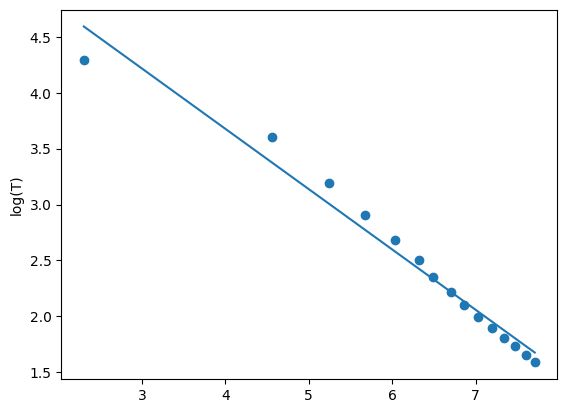

In [3]:
from numpy import log
import numpy as np
from numpy import average as avg
import matplotlib.pyplot as plt
from scipy.special import factorial

t=range(35,50)
time=[10, 95, 190, 290, 415, 555, 655, 815, 960, 1135, 1330, 1540, 1770, 2000,2230]
delta_t=[50-temp for temp in t[::-1]]
tnorm=50-23
xu=[1-log(t/tnorm) for t in delta_t]
piz=[log(t) for t in time]
b, a = np.polyfit(piz, xu, 1)
print(b, a)
plt.scatter(piz, xu)
plt.ylabel('log(T)')
plt.xlabel('time')
plt.plot(piz, [b*t+a for t in piz])

### Зависимость $T$ от $t$

Содержимое файла table1.txt:

0	23	41	62	119	193	236	289	335	391	434	482,9	539	601	685	756	811	897	984	1049	1162	1242	1340	1453	1545	1664	1796
70	69	68	67	66	65	64	63	62	61	60	59	58	57	56	55	54	53	52	51	50	49	48	47	46	45	44

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
%matplotlib inline

In [12]:
coordinates = []

with open('table1.txt', 'r') as Data:
    lines = Data.readlines()
    for i in range(0, len(lines) - 1, 2):
        x_line = lines[i].replace(',', '.').strip()
        y_line = lines[i+1].replace(',', '.').strip()

        x_coords = list(map(float, x_line.split()))
        y_coords = list(map(float, y_line.split()))

        coordinates.append(x_coords)
        coordinates.append(y_coords)

In [13]:
print(coordinates)

[[0.0, 23.0, 41.0, 62.0, 119.0, 193.0, 236.0, 289.0, 335.0, 391.0, 434.0, 482.9, 539.0, 601.0, 685.0, 756.0, 811.0, 897.0, 984.0, 1049.0, 1162.0, 1242.0, 1340.0, 1453.0, 1545.0, 1664.0, 1796.0], [70.0, 69.0, 68.0, 67.0, 66.0, 65.0, 64.0, 63.0, 62.0, 61.0, 60.0, 59.0, 58.0, 57.0, 56.0, 55.0, 54.0, 53.0, 52.0, 51.0, 50.0, 49.0, 48.0, 47.0, 46.0, 45.0, 44.0]]


In [14]:
def coefficient_reg_inv(x, y):
    size = len(x)
    A = np.empty((2, 2))
    A[[0], [0]] = sum((x[i])**2 for i in range(size))
    A[[0], [1]] = sum(x)
    A[[1], [0]] = sum(x)
    A[[1], [1]] = size
    A = np.linalg.inv(A)
    C = np.empty((2, 1))
    C[0] = sum((x[i] * y[i]) for i in range(size))
    C[1] = sum(y[i] for i in range(size))

    ww = np.dot(A, C)
    return ww[1], ww[0]

[np.float64(-18.75150475795064), np.float64(-18.76589349540274), np.float64(-18.780492294823894), np.float64(-18.795307380609035), np.float64(-18.810345257973573), np.float64(-18.825612730104364), np.float64(-18.841116916640328), np.float64(-18.856865273608467), np.float64(-18.872865614954907), np.float64(-18.88912613582669), np.float64(-18.9056554377779), np.float64(-18.92246255609428), np.float64(-18.939556989453582), np.float64(-18.95694873216545), np.float64(-18.97464830926485), np.float64(-18.992666814767528), np.float64(-19.011015953435724), np.float64(-19.02970808644788), np.float64(-19.048756281418573), np.float64(-19.068174367275674), np.float64(-19.087976994571854), np.float64(-19.108179701889373), np.float64(-19.128798989092108), np.float64(-19.14985239828994), np.float64(-19.171358603510903), np.float64(-19.193337510229682), np.float64(-19.21581036608174)]
[   0.    23.    41.    62.   119.   193.   236.   289.   335.   391.
  434.   482.9  539.   601.   685.   756.   811. 

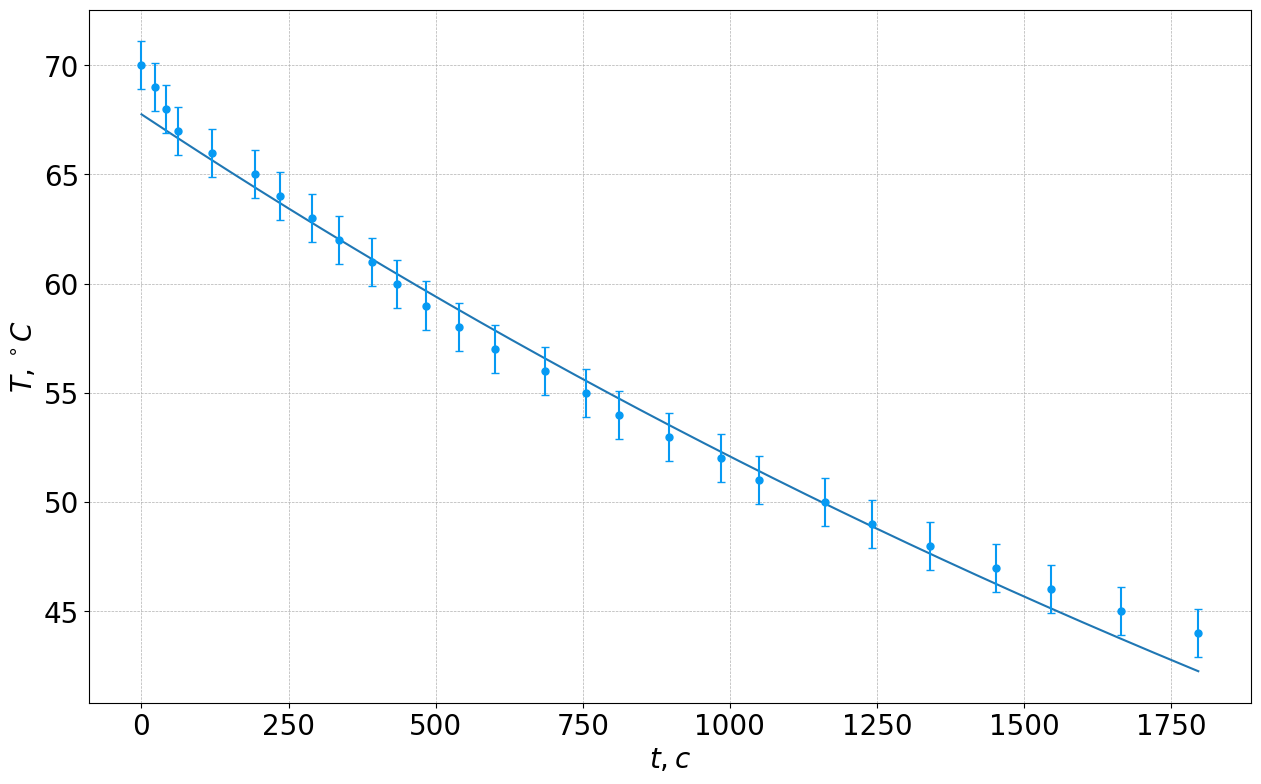

In [15]:
fig, ax1 = plt.subplots(figsize=(15, 9))
font = {'family': 'sans-serif', 'weight': 'normal', 'size': 20}
plt.rc('font', **font)


#ax1.set_title('Аппроксимация зависимости T от t')
ax1.set_xlabel(r'$t, с$')
ax1.set_ylabel(r'$T, ^\circ C$')
ax1.grid(linestyle='--', linewidth=0.5)


x_coords = np.array(coordinates[0])
y_coords = np.array(coordinates[1])

# Линейная аппроксимация
#b_lin, a_lin = coefficient_reg_inv(x_coords, y_coords)
#print(f'Линейная аппроксимация: a = {a_lin}, b = {b_lin}')
x_range = np.linspace(min(x_coords), max(x_coords), 500)
##y_lin_approx = a_lin * x_range + b_lin
#ax1.plot(x_range, y_lin_approx, label='Линейная аппроксимация', color='b')

# Экспоненциальная аппроксимация
log_y_cords = np.log(y_coords)
log_y_coords = [log_y_cords[i] - 23 for i in range(len(log_y_cords))]
print(log_y_coords)
print(x_coords)
b_exp_log, a_exp = coefficient_reg_inv(x_coords, log_y_cords)
b_exp = np.exp(b_exp_log)
a_exp = -0.00026287
print(f'Экспоненциальная аппроксимация: a = {a_exp}, b = {b_exp}, c = 23')
y_exp_approx = b_exp * np.exp(a_exp * x_range)
ax1.plot(x_range, y_exp_approx)


ax1.errorbar(x_coords, y_coords, yerr=1.1, fmt='o', color='#069AF3', capsize=3, markersize=5, elinewidth=1.5)
#ax1.legend()


plt.show()

In [17]:
"""
fig, ax1 = plt.subplots(figsize=(15, 9))
font = {'family': 'sans-serif', 'weight': 'normal', 'size': 20}
plt.rc('font', **font)


#ax1.set_title('Аппроксимация зависимости T от t')
ax1.set_xlabel(r'$t, с$')
ax1.set_ylabel(r'$\log{(1-T)}$')
ax1.grid(linestyle='--', linewidth=0.5)


x_coords = np.array(coordinates[0])
y_coords = np.array(coordinates[1])

# Линейная аппроксимация
#b_lin, a_lin = coefficient_reg_inv(x_coords, y_coords)
#print(f'Линейная аппроксимация: a = {a_lin}, b = {b_lin}')
x_range = np.linspace(min(x_coords), max(x_coords), 500)
#y_lin_approx = a_lin * x_range + b_lin
#ax1.plot(x_range, y_lin_approx, label='Линейная аппроксимация', color='b')

delta_y = []
for i in range(len(y_coords) - 1):
    delta_y.append(y_coords[i+1] - y_coords[i])

delta_y = np.array(delta_y)

x_coords = x_coords[:-1]

log_1_minus_y = np.log(1 - delta_y)
print(log_1_minus_y)
print(x_coords)
b_lin, a_lin = coefficient_reg_inv(x_coords, log_1_minus_y)
print(f'Линейная аппроксимация log(1-y): a = {a_lin}, b = {b_lin}')
y_lin_approx = a_lin * x_range + b_lin
#plt.scatter(x_range, y_lin_approx)
ax1.plot(x_range, y_lin_approx)



#ax1.errorbar(x_coords, y_coords, yerr=0.5, fmt='o', color='#069AF3', capsize=3, markersize=5, elinewidth=1.5)
#ax1.legend()

"""


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3117/4170068579.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel(r'$\log{(1-T)}$')


"\nfig, ax1 = plt.subplots(figsize=(15, 9))\nfont = {'family': 'sans-serif', 'weight': 'normal', 'size': 20}\nplt.rc('font', **font)\n\n\n#ax1.set_title('Аппроксимация зависимости T от t')\nax1.set_xlabel(r'$t, с$')\nax1.set_ylabel(r'$\\log{(1-T)}$')\nax1.grid(linestyle='--', linewidth=0.5)\n\n\nx_coords = np.array(coordinates[0])\ny_coords = np.array(coordinates[1])\n\n# Линейная аппроксимация\n#b_lin, a_lin = coefficient_reg_inv(x_coords, y_coords)\n#print(f'Линейная аппроксимация: a = {a_lin}, b = {b_lin}')\nx_range = np.linspace(min(x_coords), max(x_coords), 500)\n#y_lin_approx = a_lin * x_range + b_lin\n#ax1.plot(x_range, y_lin_approx, label='Линейная аппроксимация', color='b')\n\ndelta_y = []\nfor i in range(len(y_coords) - 1):\n    delta_y.append(y_coords[i+1] - y_coords[i])\n\ndelta_y = np.array(delta_y)\n\nx_coords = x_coords[:-1]\n\nlog_1_minus_y = np.log(1 - delta_y)\nprint(log_1_minus_y)\nprint(x_coords)\nb_lin, a_lin = coefficient_reg_inv(x_coords, log_1_minus_y)\nprint(f'

Коэффициенты аппроксимирующей прямой:
k (угловой коэффициент) = 1.001685
b (свободный член) = 0.079441
Уравнение прямой: y = 1.001685*x + 0.079441


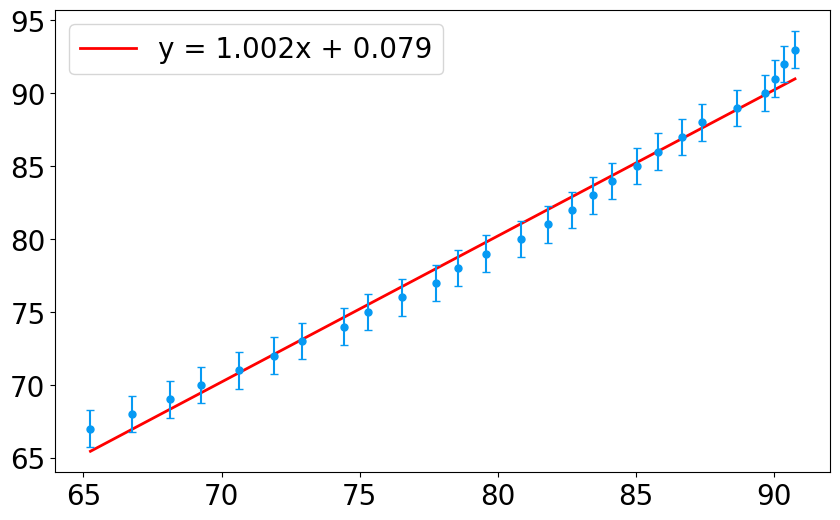

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Чтение данных из файла
with open('table1.txt', 'r') as file:
    content = file.read()

# Замена запятых на точки
content = content.replace(',', '.')
lines = content.strip().split('\n')

# Извлечение данных
y_values = list(map(float, lines[1].split()))  # первая строчка - y
x_values = list(map(float, lines[0].split()))  # вторая строчка - x

# Параметры
a = -0.00026287
b = 67.75258548
c = 23

# Вычисление новых координат
new_x = [b * np.exp(a * x) + c for x in x_values]
new_y = [y + 23 for y in y_values]

coefficients = np.polyfit(new_x, new_y, 1)
k = coefficients[0]  # угловой коэффициент
b_line = coefficients[1]  # свободный член (переименовал для избежания конфликта)

print(f"Коэффициенты аппроксимирующей прямой:")
print(f"k (угловой коэффициент) = {k:.6f}")
print(f"b (свободный член) = {b_line:.6f}")
print(f"Уравнение прямой: y = {k:.6f}*x + {b_line:.6f}")

# Построение графика
plt.figure(figsize=(10, 6))
#plt.scatter(new_x, new_y, color='blue', alpha=0.7, label='Данные')

# Построение аппроксимирующей прямой
x_line = np.linspace(min(new_x), max(new_x), 100)
y_line = k * x_line + b_line
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {k:.3f}x + {b_line:.3f}')

# Построение графика
#plt.figure(figsize=(10, 6))
#plt.scatter(new_x, new_y, color='blue', alpha=0.7)
#plt.xlabel('b*exp(a*x) + c')
#plt.ylabel('y')
#plt.title('График точек [b*exp(a*x)+c, y]')
#plt.grid(True, alpha=0.3)
y_err=1.25

plt.errorbar(new_x, new_y, yerr=y_err, fmt='o', color='#069AF3', capsize=3, markersize=5, elinewidth=1.5)
plt.legend()
plt.show()
